# 1) Đọc dữ liệu


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import unicodedata
from pathlib import Path
from collections import defaultdict
from matplotlib.ticker import FuncFormatter, FixedLocator
from IPython.display import display


df_store = pd.read_csv("../data/stores.csv")
df_category = pd.read_csv("../data/categories.csv")
df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# 2) Phân tích kích thước mẫu

In [2]:
print("STORE:", df_store.shape)
print("CATEGORY:", df_category.shape)
print("PRODUCT:", df_product.shape)
print("REVIEW:", df_review.shape)

STORE: (1446, 5)
CATEGORY: (496, 4)
PRODUCT: (55883, 14)
REVIEW: (158126, 9)


# 3) Phân tích cấu trúc dữ liệu

## Tên cột và loại dữ liệu

In [3]:
print("===== STORE INFO =====")
print(df_store.info())

print("\n===== CATEGORY INFO =====")
print(df_category.info())

print("\n===== PRODUCT INFO =====")
print(df_product.info())

print("\n===== REVIEW INFO =====")
print(df_review.info())

===== STORE INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1446 entries, 0 to 1445
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   store_id         1446 non-null   int64  
 1   store_name       1446 non-null   object 
 2   store_rating     1446 non-null   float64
 3   follower_count   1446 non-null   int64  
 4   source_category  1446 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 56.6+ KB
None

===== CATEGORY INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   category_id      496 non-null    int64 
 1   category_name    496 non-null    object
 2   parent_category  491 non-null    object
 3   source_category  496 non-null    object
dtypes: int64(1), object(3)
memory usage: 15.6+ KB
None

===== PRODUCT INFO ====

## Kiểm tra giá trị thiếu

In [4]:
print("\nMissing values:")
print(df_store.isnull().sum())

print(df_category.isnull().sum())
print(df_product.isnull().sum())
print(df_review.isnull().sum())


Missing values:
store_id           0
store_name         0
store_rating       0
follower_count     0
source_category    0
dtype: int64
category_id        0
category_name      0
parent_category    5
source_category    0
dtype: int64
product_id            0
store_id            860
category_id           0
product_name          0
product_url           0
brand                 2
description          53
price                 0
original_price        0
discount_percent      0
sold_count            0
rating_avg            0
review_count          0
source_category       0
dtype: int64
review_id                0
product_id               0
user_name                3
rating                   0
review_text              1
like_count               0
review_date              0
source_category          0
cleaned_review_text    217
dtype: int64


# 4) Thống kê mô tả các biến số

In [5]:
print(df_store[['store_rating','follower_count']].describe())
print(df_product['price'].describe())
print(df_review[['rating','like_count']].describe())

       store_rating  follower_count
count   1446.000000     1446.000000
mean       3.222462      785.340941
std        2.018953    14132.360500
min        0.000000        0.000000
25%        0.000000        0.000000
50%        4.340500        2.000000
75%        4.644325       73.500000
max        5.000000   512930.000000
count    5.588300e+04
mean     2.377133e+06
std      1.112896e+07
min      1.800000e+03
25%      8.900000e+04
50%      3.096000e+05
75%      1.250000e+06
max      8.178840e+08
Name: price, dtype: float64
              rating     like_count
count  158126.000000  158126.000000
mean        4.681355       0.211591
std         0.837277       1.948833
min         1.000000       0.000000
25%         5.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000     289.000000


# 5) Thống kê các biến quan trọng

## Thống kê giá sản phẩm

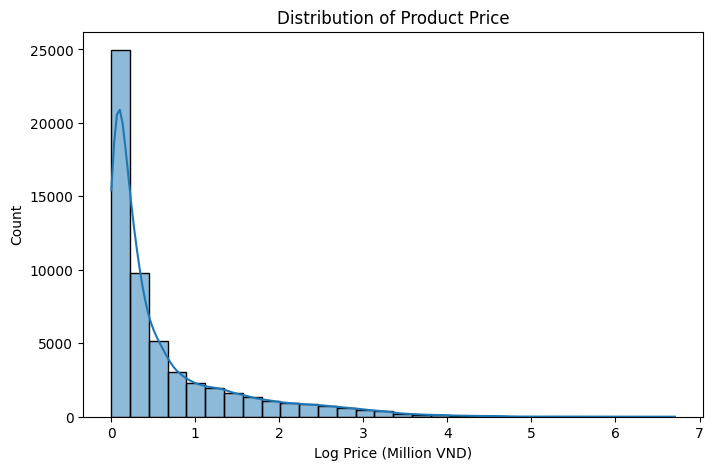

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_product["price"] / 1e6), bins=30, kde=True)
#sns.histplot(df_product["price"], bins=30, kde=True)
plt.title("Distribution of Product Price")
plt.xlabel("Log Price (Million VND)")
plt.show()

## Phân số số lượng bán

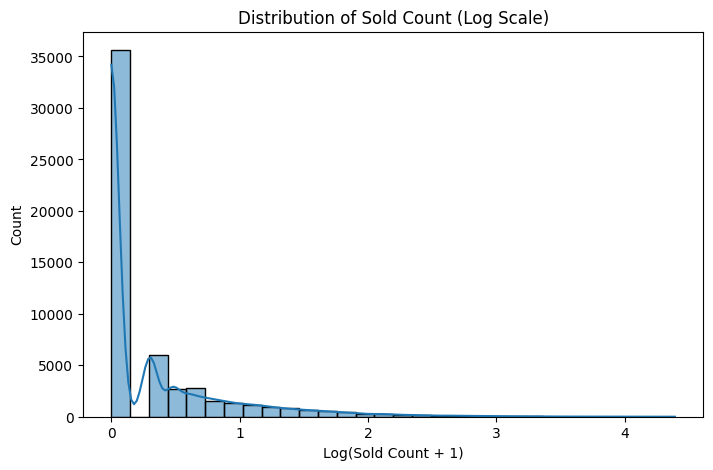

In [7]:
#lấy log để dễ nhìn hơn, vì giá có thể có nhiều outlier
plt.figure(figsize=(8,5))
sns.histplot(np.log10(df_product["sold_count"] + 1), bins=30, kde=True)
plt.title("Distribution of Sold Count (Log Scale)")
plt.xlabel("Log(Sold Count + 1)")
plt.show()

## Phân bố rating cửa hàng

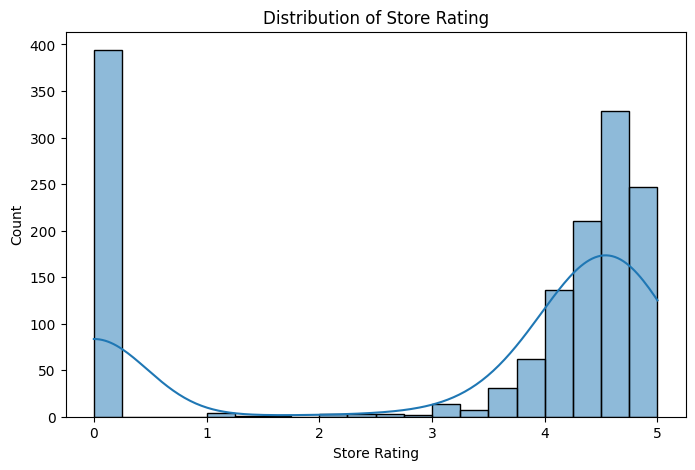

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df_store["store_rating"], bins=20, kde=True)
plt.title("Distribution of Store Rating")
plt.xlabel("Store Rating")
plt.show()

## Phân bố rating sản phẩm

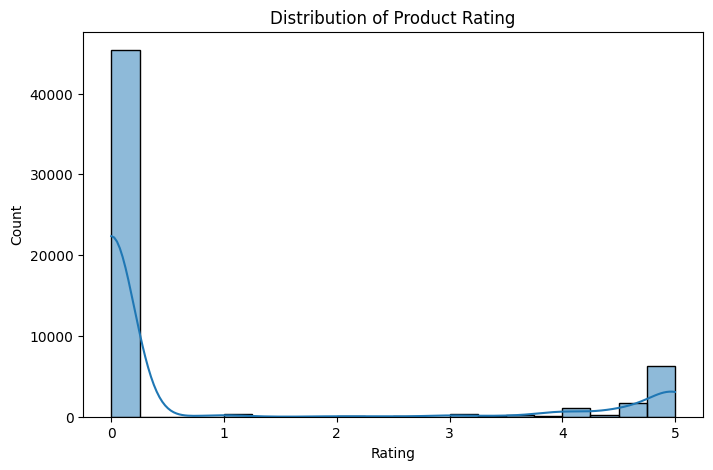

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_product["rating_avg"], bins=20, kde=True)
plt.title("Distribution of Product Rating")
plt.xlabel("Rating")
plt.show()

# 6) Phân bố biến phân loại

### Biểu đồ tương tác cho toàn bộ cây category

Mục đích: Khám phá rõ hơn mối quan hệ giữa các category, đặc biệt là các category con và category cha, để từ đó có thể thiết kế biểu đồ tương tác phù hợp.

In [10]:
df_cat_product = df_product.merge(df_category, on="category_id", how="left")

cat_count = (
    df_cat_product.groupby(["parent_category", "category_name"])
    .size()
    .reset_index(name="product_count")
)

cat_count["parent_category"] = cat_count["parent_category"].fillna("Tiki Categories")

fig = px.treemap(
    cat_count,
    path=["parent_category", "category_name"],
    values="product_count",
    title="Category Treemap"
)

fig.show()


#### Một cách trực quan hơn các nhóm category

In [11]:
if "df_category" in globals():
    categories_sunburst = df_category.copy()
else:
    categories_sunburst = pd.read_csv(Path("../data/categories.csv"))

required_cols = {"category_id", "category_name", "parent_category"}
missing_cols = required_cols - set(categories_sunburst.columns)
if missing_cols:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_cols}")

if "source_category" not in categories_sunburst.columns:
    categories_sunburst["source_category"] = ""

sunburst_df = categories_sunburst[["category_id", "category_name", "parent_category", "source_category"]].copy()
sunburst_df["category_id"] = sunburst_df["category_id"].astype(str).str.strip()
sunburst_df["category_name"] = sunburst_df["category_name"].astype(str).str.strip()
sunburst_df["parent_category"] = sunburst_df["parent_category"].fillna("").astype(str).str.strip()
sunburst_df["source_category"] = sunburst_df["source_category"].fillna("").astype(str).str.strip()

# 5 root cần focus
roots_to_focus = [
    "Laptop - May vi tinh - Linh kien",
    "Dien thoai - May tinh bang",
    "Thiet bi so - Phu kien so",
    "Dien gia dung",
    "Dien tu - Dien lanh",
]

def normalize_text(s: str) -> str:
    s = str(s).strip().lower()
    s = s.replace("đ", "d")
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return " ".join(s.split())

# Tạo key để map parent -> child theo ID, tránh lỗi trùng category_name
sunburst_df["name_key"] = sunburst_df["category_name"].apply(normalize_text)
sunburst_df["source_key"] = sunburst_df["source_category"].apply(normalize_text)
sunburst_df["node_id"] = sunburst_df["category_id"]

name_source_to_ids = defaultdict(list)
name_to_ids = defaultdict(list)
for _, row in sunburst_df.iterrows():
    name_source_to_ids[(row["source_key"], row["name_key"])].append(row["node_id"])
    name_to_ids[row["name_key"]].append(row["node_id"])

def resolve_parent_id(row):
    parent_name = row["parent_category"]
    if parent_name == "":
        return ""

    parent_key = normalize_text(parent_name)
    source_key = row["source_key"]

    candidates = list(dict.fromkeys(name_source_to_ids.get((source_key, parent_key), [])))
    if len(candidates) == 1:
        return candidates[0]

    candidates = list(dict.fromkeys(name_to_ids.get(parent_key, [])))
    if len(candidates) == 1:
        return candidates[0]

    return candidates[0] if len(candidates) > 0 else ""

sunburst_df["parent_id"] = sunburst_df.apply(resolve_parent_id, axis=1)

# Build cây parent_id -> child_id
children_map = defaultdict(list)
for _, row in sunburst_df.iterrows():
    parent_id = row["parent_id"]
    if parent_id != "":
        children_map[parent_id].append(row["node_id"])

def get_all_descendants(root_id: str):
    keep = set()
    stack = [root_id]
    while stack:
        cur = stack.pop()
        if cur in keep:
            continue
        keep.add(cur)
        stack.extend(children_map.get(cur, []))
    return keep

for root in roots_to_focus:
    root_key = normalize_text(root)
    root_candidates = list(dict.fromkeys(name_to_ids.get(root_key, [])))

    if len(root_candidates) == 0:
        print(f"Không tìm thấy root trong categories: {root}")
        continue

    top_level_candidates = [
        rid for rid in root_candidates
        if sunburst_df.loc[sunburst_df["node_id"] == rid, "parent_id"].iloc[0] == ""
    ]
    root_id = top_level_candidates[0] if top_level_candidates else root_candidates[0]

    keep_ids = get_all_descendants(root_id)

    df_root = sunburst_df[sunburst_df["node_id"].isin(keep_ids)].copy()
    df_root = df_root[["node_id", "category_name", "parent_id"]].drop_duplicates(subset=["node_id"])

    # đảm bảo root là nút gốc trong chart này
    df_root.loc[df_root["node_id"] == root_id, "parent_id"] = ""

    real_root = df_root.loc[df_root["node_id"] == root_id, "category_name"].iloc[0]

    fig = px.sunburst(
        df_root,
        ids="node_id",
        names="category_name",
        parents="parent_id",
        title=f"Sunburst cho root: {real_root}",
    )
    
    fig.update_layout(
        height=850,
        width=1000,
        margin=dict(t=70, l=10, r=10, b=10),
        uniformtext=dict(minsize=9, mode="hide"),
    )

fig.show()

## Số lượng sản phẩm theo danh mục

In [12]:
sns.set_theme(style="whitegrid")
main_cmap = sns.color_palette("mako", as_cmap=True)

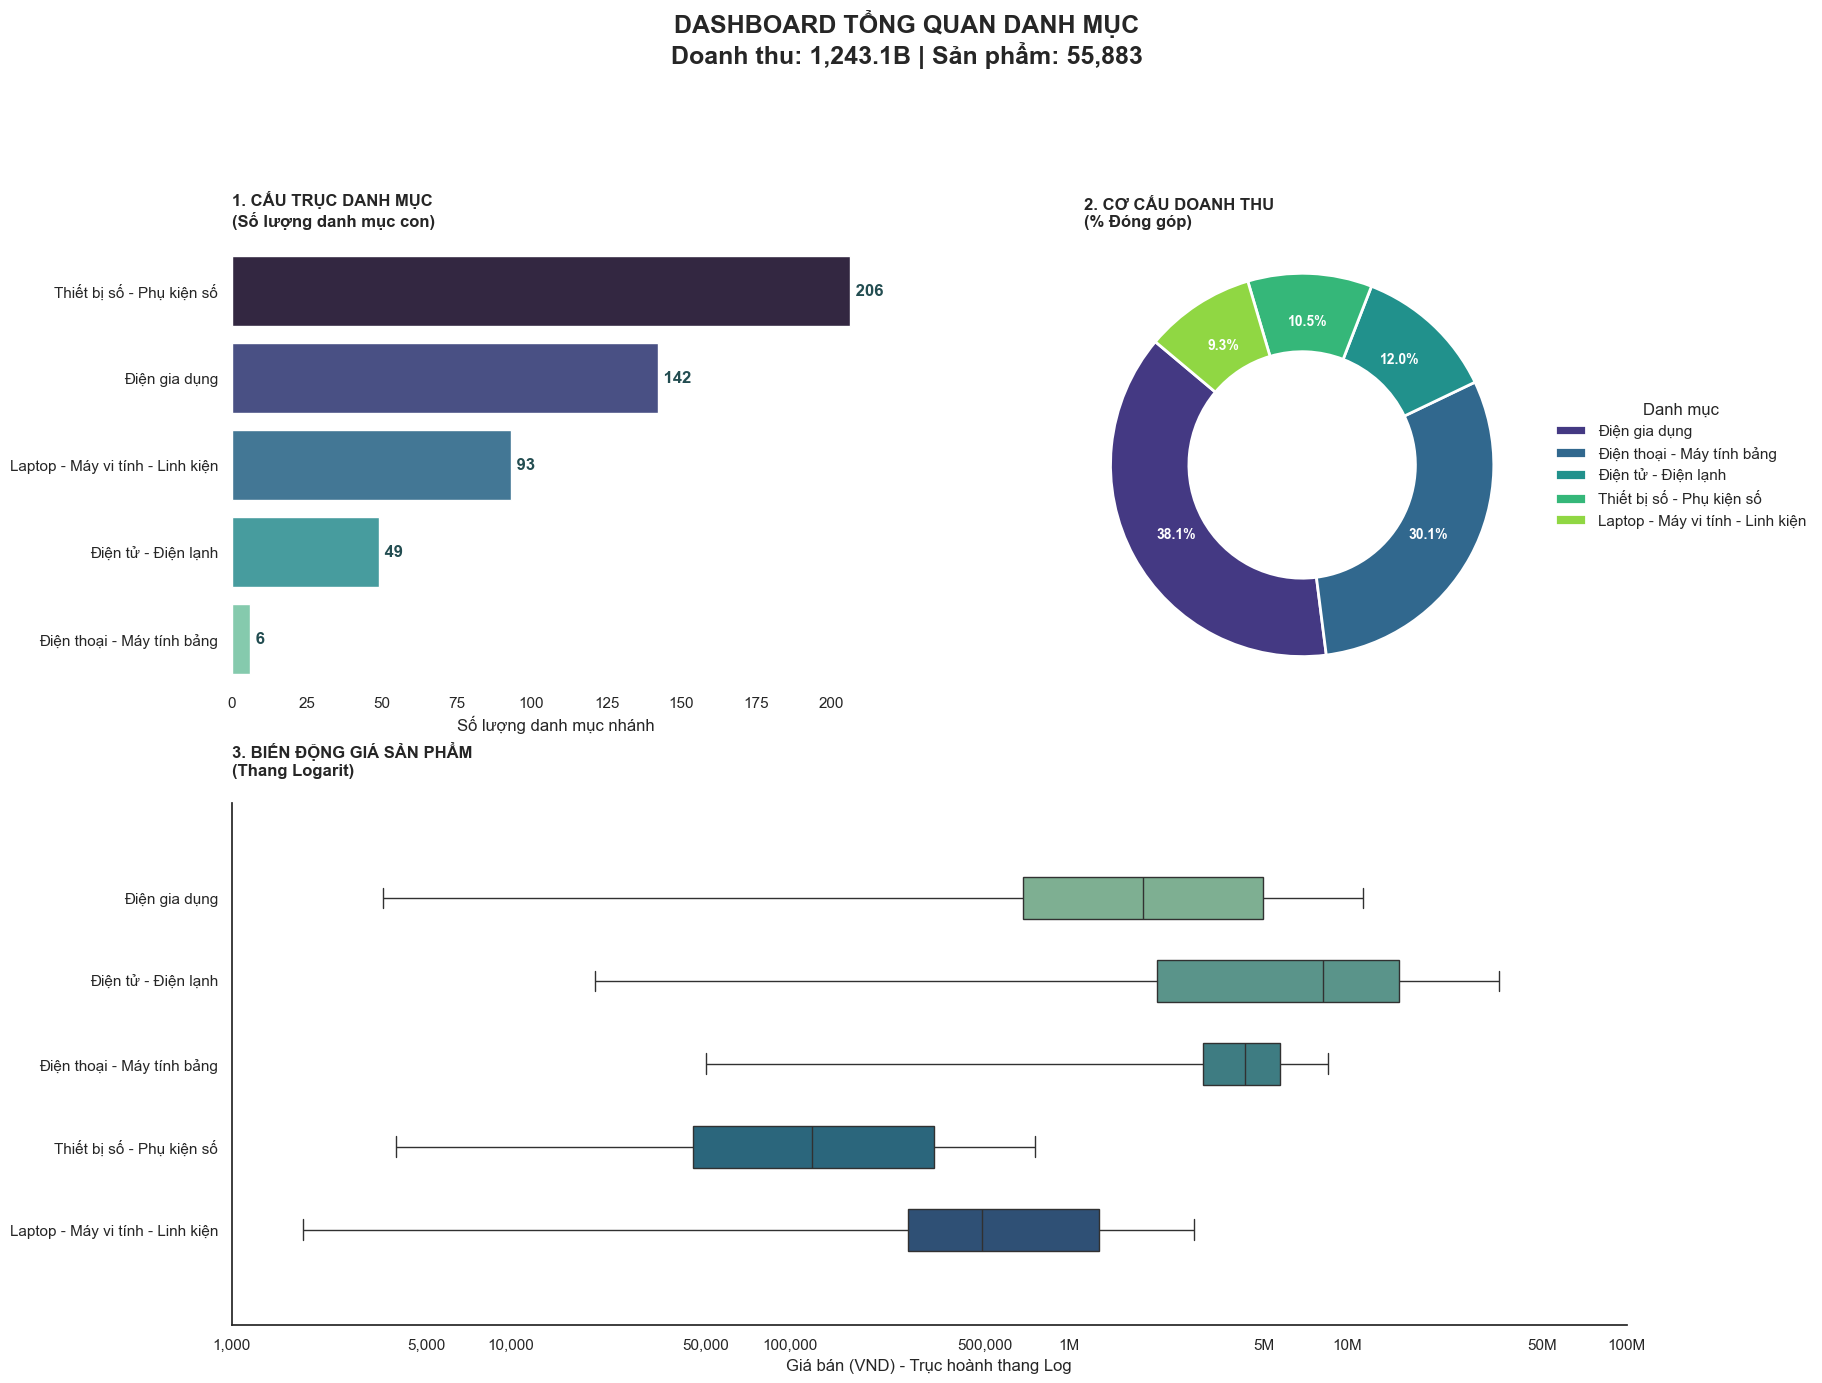

In [ ]:


parent_dict = dict(zip(df_category['category_name'], df_category['parent_category'])) 
root_categories = set(
    df_category[
        df_category["parent_category"].isna() |
        (df_category["parent_category"] == "")
    ]["category_name"]
)

parent_dict = dict(zip(
    df_category["category_name"],
    df_category["parent_category"]
))

def find_root(cat_name):
    checked = set()
    current = cat_name

    while pd.notna(current) and current != "":
        if current in root_categories:
            return current

        if current in checked:
            break

        checked.add(current)
        current = parent_dict.get(current)

    return "Unknown"

# Apply cho toàn bộ category
df_category["root_category"] = df_category["category_name"].apply(find_root)

# Tạo dict mapping cho map bên dưới
cat_to_root_dict = dict(zip(df_category['category_id'].astype(str), df_category['root_category']))

df_product_eda = df_product.copy()
df_product_eda['category_id'] = df_product_eda['category_id'].astype(str)
df_product_eda['root_category'] = df_product_eda['category_id'].map(cat_to_root_dict)
df_product_eda['price'] = pd.to_numeric(df_product_eda['price'], errors='coerce').fillna(0)
df_product_eda['sold_count'] = pd.to_numeric(df_product_eda['sold_count'], errors='coerce').fillna(0)
df_product_eda['revenue'] = df_product_eda['price'] * df_product_eda['sold_count']

plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="white", palette="crest")
MAIN_COLOR = "#234d51"

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.2],
    width_ratios=[1, 1],
    hspace=0.25,
    wspace=0.15
)

def format_money(x, pos):
    if x >= 1_000_000_000: return f'{x / 1_000_000_000:,.1f}B'
    if x >= 1_000_000: return f'{x / 1_000_000:,.0f}M'
    return f'{x:,.0f}'

ax1 = fig.add_subplot(gs[0, 0])
# Chuẩn bị DataFrame cho barplot, có cột root_category để gán làm hue theo khuyến nghị mới của seaborn
sub_cat_count_df = df_category[df_category['parent_category'] != '']
sub_cat_count_df = sub_cat_count_df[~sub_cat_count_df['root_category'].isna()]
sub_cat_count_df = sub_cat_count_df.groupby('root_category')['category_id'].count().sort_values(ascending=False).reset_index()
sub_cat_count_df = sub_cat_count_df.rename(columns={'category_id': 'count'})
# Vẽ barplot, sử dụng "hue" là root_category, legend=False để tránh warning palette
sns.barplot(
    data=sub_cat_count_df,
    x='count', y='root_category', hue='root_category', # Bổ sung hue='root_category'
    palette="mako",
    ax=ax1,
    legend=False # Không vẽ legend
)
ax1.set_title('1. CẤU TRỤC DANH MỤC\n(Số lượng danh mục con)', loc='left', fontweight='bold', pad=15)
ax1.set_xlabel('Số lượng danh mục nhánh')
ax1.set_ylabel('')

for i, v in enumerate(sub_cat_count_df['count']):
    ax1.text(v + 0.5, i, f' {int(v)}', va='center', fontweight='bold', color=MAIN_COLOR)
sns.despine(ax=ax1, left=True, bottom=True)

ax2 = fig.add_subplot(gs[0, 1])
# Lọc bỏ các sản phẩm ko xác định được root_category
revenue_by_root = df_product_eda[~df_product_eda['root_category'].isna()]
revenue_by_root = revenue_by_root.groupby('root_category')['revenue'].sum().sort_values(ascending=False)
revenue_by_root = revenue_by_root[revenue_by_root > 0]

wedges, texts, autotexts = ax2.pie(
    revenue_by_root.values, 
    autopct='%1.1f%%',
    startangle=140, 
    pctdistance=0.75,
    radius=1.1,
    colors=sns.color_palette("viridis", len(revenue_by_root)),
    wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 2}
)

ax2.legend(
    wedges, revenue_by_root.index,
    title="Danh mục",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.setp(autotexts, size=10, weight="bold", color="white")
ax2.set_title(
    '2. CƠ CẤU DOANH THU\n(% Đóng góp)',
    loc='left',
    fontweight='bold',
    pad=15
)

ax3 = fig.add_subplot(gs[1, :])
# Lọc các sản phẩm xác định được root_category
top5_roots_by_items = df_product_eda['root_category'].value_counts().head(5).index
df_boxplot = df_product_eda[(df_product_eda['root_category'].isin(top5_roots_by_items)) & (df_product_eda['price'] > 0)]

# Vẽ boxplot, thêm hue='root_category' và legend=False để tránh warning với palette
sns.boxplot(
    data=df_boxplot, x='price', y='root_category',
    hue='root_category',         # Bổ sung hue y thành hue='root_category'
    palette="crest", 
    showfliers=False, 
    ax=ax3, 
    width=0.5,
    legend=False                 # Không vẽ legend
)

ax3.set_xscale('log')
major_ticks = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8]
ax3.set_xticks(major_ticks)
ax3.xaxis.set_major_formatter(FuncFormatter(format_money))

ax3.margins(y=0.2)
ax3.set_title(
    '3. BIẾN ĐỘNG GIÁ SẢN PHẨM \n(Thang Logarit)',
    loc='left',
    fontweight='bold',
    pad=20
)

ax3.set_xlabel('Giá bán (VND) - Trục hoành thang Log')
ax3.set_ylabel('')
sns.despine(ax=ax3)

total_rev = df_product_eda['revenue'].sum()
fig.suptitle(
    f"DASHBOARD TỔNG QUAN DANH MỤC\nDoanh thu: {format_money(total_rev, None)} | Sản phẩm: {len(df_product_eda):,}",
    fontsize=18,
    fontweight='bold',
    y=1.05   
)
for ax in [ax1, ax2, ax3]:
    ax.title.set_ha('left')
    ax.title.set_position((0, 1.02))
# (Bỏ dòng thừa vẽ fig mới bên dưới)
plt.show()

In [14]:
df_product_category = df_product.merge(
    df_category,
    on="category_id",
    how="left"
)

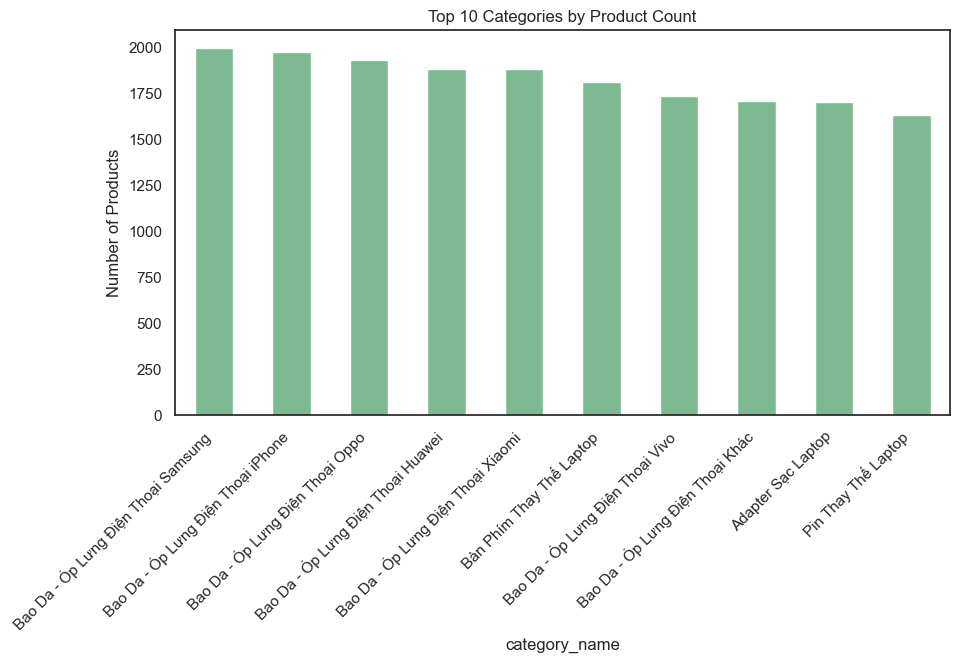

In [15]:
plt.figure(figsize=(10,5))
df_product_category["category_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Categories by Product Count")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.show()